In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, RocCurveDisplay
from utils import get_data, get_binned_stratified_data, confusion, print_final_results
from sklearn.exceptions import ConvergenceWarning
import warnings


In [2]:
seed = 42
penalty = [None, 'l1', 'l2', 'elasticnet']
solvers = ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag', 'saga', 'liblinear']
cs = [0.001, 0.01, 1, 1.001, 1.01, 1.1, 2, 5, 100]

In [3]:
def test_everything(wine_X_tr, wine_y_tr, wine_X_val, wine_y_val):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ConvergenceWarning)
        warnings.simplefilter("ignore", category=UserWarning)
        for solv in solvers:
            l1rat = 0
            for pen in penalty:
                match pen:
                    case 'elasticnet':
                        l1rat = 0.5
                    case 'l1':
                        l1rat = 1
                try:
                    max_c = 0
                    max_val_accuracy = 0
                    max_classifier = LogisticRegression(solver=solv, penalty=pen, max_iter = 1, random_state = seed)
                    for c in cs:
                        classifier = LogisticRegression(solver=solv, penalty=pen, max_iter = 100, C=c, l1_ratio=l1rat, random_state = seed);
                        classifier.fit(wine_X_tr, wine_y_tr);
                        if(100*accuracy_score(wine_y_val, classifier.predict(wine_X_val)) > max_val_accuracy):
                            max_val_accuracy = 100*accuracy_score(wine_y_val, classifier.predict(wine_X_val))
                            max_classifier = classifier 
                            max_c = c
                    print(f'Params: solver: {solv}, penalty: {pen}, C: {max_c}')
                    print(f'Training accuracy: {100*accuracy_score(wine_y_tr, max_classifier.predict(wine_X_tr)):.2f}%' )
                    print(f'Validation accuracy: {100*accuracy_score(wine_y_val, max_classifier.predict(wine_X_val)):.2f}%\n' )
                except ValueError:
                    continue

In [4]:
# wine_X_tr, wine_X_val, wine_X_test, wine_y_tr, wine_y_val, wine_y_test = get_binned_stratified_data(seed) # pyright: ignore[reportGeneralTypeIssues]
# test_everything(wine_X_tr, wine_y_tr, wine_X_val, wine_y_val)

In [5]:
# classifier =  LogisticRegression(solver='lbfgs', penalty='l2', max_iter = 100, random_state = seed, C=2)
# confusion(classifier, wine_X_tr, wine_y_tr, wine_X_val, wine_y_val)  


In [6]:
# print_final_results(classifier, wine_X_tr, wine_y_tr, wine_X_val, wine_y_val, wine_X_test, wine_y_test)

In [7]:
wine_X_tr, wine_X_val, wine_X_test, wine_y_tr, wine_y_val, wine_y_test = get_data(seed)
test_everything(wine_X_tr, wine_y_tr, wine_X_val, wine_y_val)

Params: solver: lbfgs, penalty: None, C: 0.001
Training accuracy: 55.26%
Validation accuracy: 54.70%

Params: solver: lbfgs, penalty: l2, C: 1.01
Training accuracy: 55.04%
Validation accuracy: 54.79%

Params: solver: newton-cg, penalty: None, C: 0.001
Training accuracy: 55.20%
Validation accuracy: 54.70%

Params: solver: newton-cg, penalty: l2, C: 1.1
Training accuracy: 54.92%
Validation accuracy: 54.79%

Params: solver: newton-cholesky, penalty: None, C: 0.001
Training accuracy: 55.20%
Validation accuracy: 54.70%

Params: solver: newton-cholesky, penalty: l2, C: 1.1
Training accuracy: 54.92%
Validation accuracy: 54.79%

Params: solver: sag, penalty: None, C: 0.001
Training accuracy: 55.14%
Validation accuracy: 54.79%

Params: solver: sag, penalty: l2, C: 2
Training accuracy: 55.04%
Validation accuracy: 54.79%

Params: solver: saga, penalty: None, C: 0.001
Training accuracy: 55.08%
Validation accuracy: 54.79%

Params: solver: saga, penalty: l1, C: 1
Training accuracy: 54.98%
Validation

In [8]:
classifier =  LogisticRegression(solver='liblinear', penalty='l1', max_iter = 100, random_state = seed, C=1)
confusion(classifier, wine_X_tr, wine_y_tr, wine_X_val, wine_y_val)   

Results:
--- Accuracy (train): 55.17%
--- Accuracy (test): 54.98%


In [9]:
print_final_results(classifier, wine_X_tr, wine_y_tr, wine_X_val, wine_y_val, wine_X_test, wine_y_test)

Results:
--- Accuracy (train): 55.17%
--- Accuracy (validation): 54.98%
--- Accuracy (test): 52.73%


In [10]:
wine_X_tr, wine_X_val, wine_X_test, wine_y_tr, wine_y_val, wine_y_test = get_data(seed, binary=True)
test_everything(wine_X_tr, wine_y_tr, wine_X_val, wine_y_val)

Params: solver: lbfgs, penalty: None, C: 0.001
Training accuracy: 75.19%
Validation accuracy: 74.25%

Params: solver: lbfgs, penalty: l2, C: 1
Training accuracy: 75.19%
Validation accuracy: 74.25%

Params: solver: newton-cg, penalty: None, C: 0.001
Training accuracy: 75.22%
Validation accuracy: 74.34%

Params: solver: newton-cg, penalty: l2, C: 100
Training accuracy: 75.22%
Validation accuracy: 74.34%

Params: solver: newton-cholesky, penalty: None, C: 0.001
Training accuracy: 75.19%
Validation accuracy: 74.25%

Params: solver: newton-cholesky, penalty: l2, C: 1
Training accuracy: 75.19%
Validation accuracy: 74.25%

Params: solver: sag, penalty: None, C: 0.001
Training accuracy: 75.19%
Validation accuracy: 74.25%

Params: solver: sag, penalty: l2, C: 1
Training accuracy: 75.19%
Validation accuracy: 74.25%

Params: solver: saga, penalty: None, C: 0.001
Training accuracy: 75.19%
Validation accuracy: 74.25%

Params: solver: saga, penalty: l1, C: 1
Training accuracy: 75.22%
Validation accu

Results:
--- Accuracy (train): 74.66%
--- Accuracy (test): 73.21%


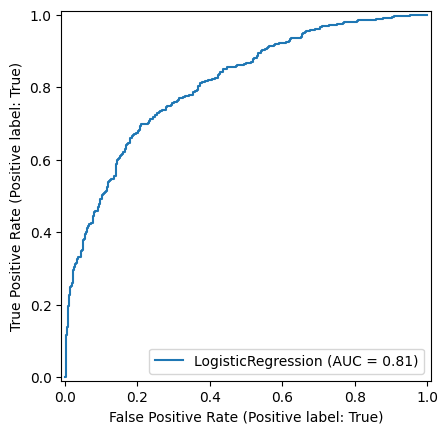

In [11]:
classifier =  LogisticRegression(solver='liblinear', penalty='l2', max_iter = 100, random_state = seed, C=0.01)
confusion(classifier, wine_X_tr, wine_y_tr, wine_X_val, wine_y_val)
disp = RocCurveDisplay.from_estimator(classifier, wine_X_val, wine_y_val)

In [12]:
print_final_results(classifier, wine_X_tr, wine_y_tr, wine_X_val, wine_y_val, wine_X_test, wine_y_test)

Results:
--- Accuracy (train): 74.66%
--- Accuracy (validation): 73.21%
--- Accuracy (test): 73.68%


In [13]:
# # Create a figure with only one subplot
# figure, axes = plt.subplots(1, figsize=(6, 6))

# ### YOUR CODE STARTS HERE ###

# errors_tr = []
# errors_te = []

# k = [1, 2, 5, 10, 50, 100, 110]
# for i in range(len(k)):
#     knn_classifier = KNeighborsClassifier(n_neighbors=k[i])
#     knn_classifier.fit(peng_X_tr, peng_y_tr)
#     y_pred = knn_classifier.predict(peng_X_tr)
#     accuracy = accuracy_score(peng_y_tr, y_pred)
#     errors_tr.append(1-accuracy)
#     y_pred = knn_classifier.predict(peng_X_te)
#     accuracy = accuracy_score(peng_y_te, y_pred)
#     errors_te.append(1-accuracy)

# axes.semilogx(k, errors_tr, c='r', label = "training")
# axes.semilogx(k, errors_te, c = 'g', label = "testing")
# axes.set_xlabel('k')
# axes.set_ylabel('error')
# axes.legend()

# ### YOUR CODE ENDS HERE ###